# 🧠 Metacognition Benchmark
## Measuring AGI Progress via Calibrated Uncertainty

> **Core Question:** Does the model know what it doesn't know?

### Why This Matters for AGI Safety
A model that is confidently wrong is **dangerous**.  
A model that knows its limits is **trustworthy**.

**Metric:** Expected Calibration Error (ECE) — lower = better self-awareness  
**AGI Target:** ECE < 0.05


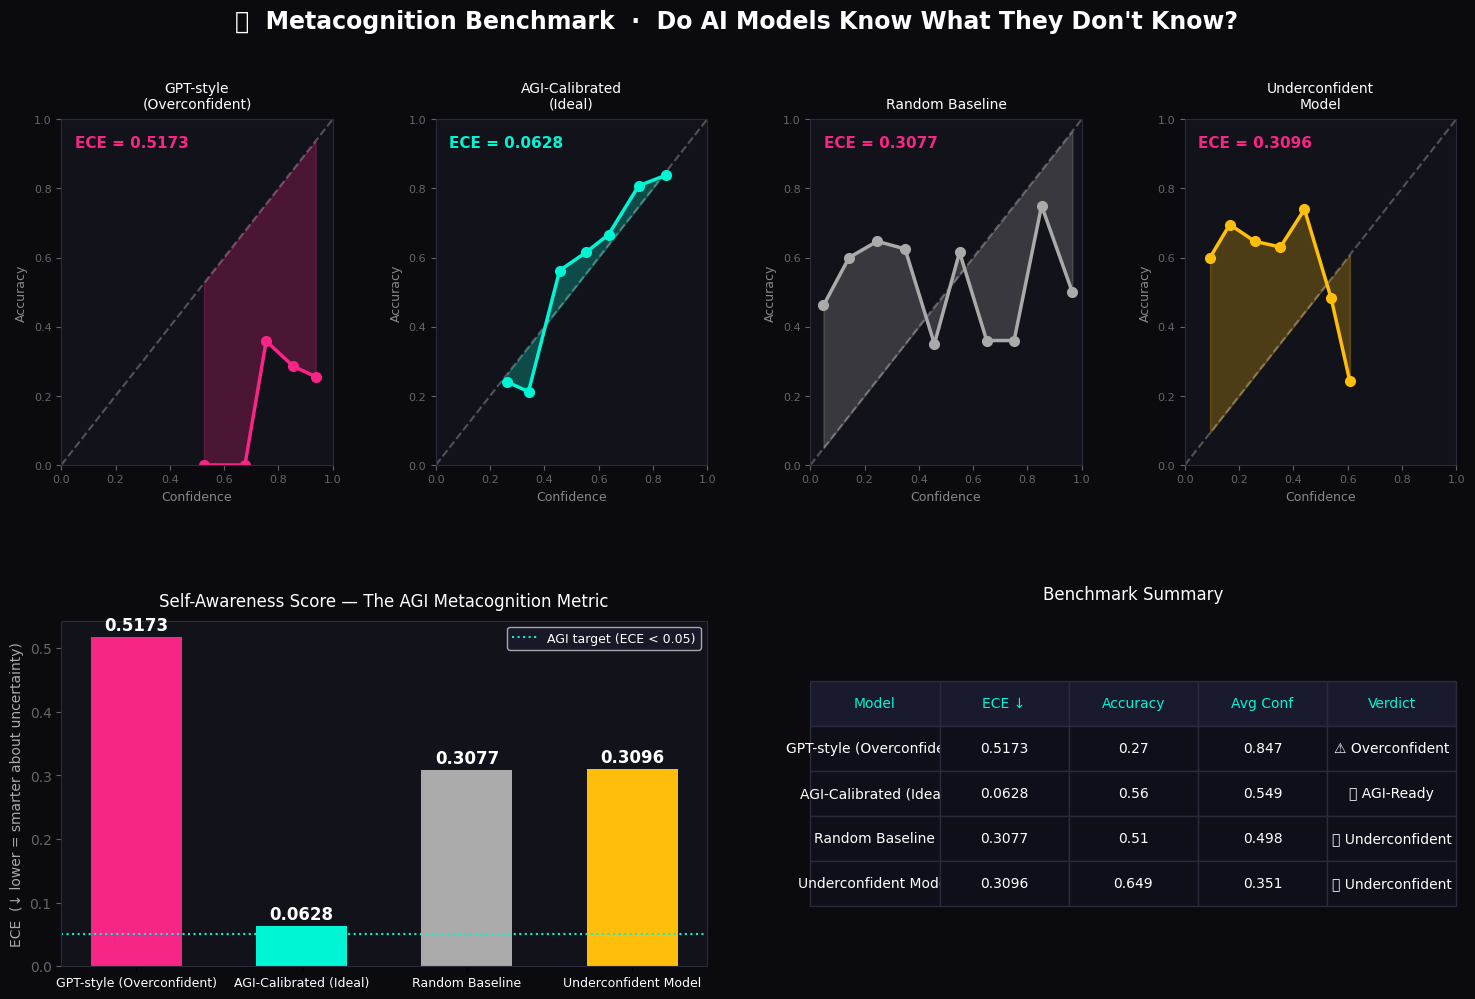


✅ Benchmark complete!
🏆 Best model ECE : 0.0628
📊 AGI target ECE : < 0.05
📁 submission.csv : saved!

💡 Key Insight: True AGI must know the limits of its own knowledge.

                     model  ece_score  accuracy  avg_confidence          verdict
GPT-style (Overconfident)     0.5173     0.270           0.847 ⚠️ Overconfident
   AGI-Calibrated (Ideal)     0.0628     0.560           0.549      🏆 AGI-Ready
          Random Baseline     0.3077     0.510           0.498 📉 Underconfident
     Underconfident Model     0.3096     0.649           0.351 📉 Underconfident


In [1]:
# ============================================================
# 🧠 METACOGNITION BENCHMARK — "Do You Know What You Don't Know?"
# Measuring AGI Progress via Calibrated Uncertainty
# By: Amin Mahmoud Ali Fayed | Kaggle x Google DeepMind Hackathon
# ============================================================

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── SIMULATED MODEL RESPONSES ─────────────────────────────────
np.random.seed(42)

def simulate_model_responses(n=100, model_type="overconfident"):
    true_answers = np.random.randint(0, 2, n)
    
    if model_type == "overconfident":
        confidences = np.clip(np.random.normal(0.85, 0.1, n), 0.1, 1.0)
        accuracies = true_answers * np.random.binomial(1, 0.6, n)
        
    elif model_type == "well_calibrated":
        confidences = np.random.uniform(0.2, 0.9, n)
        accuracies = np.array([
            np.random.binomial(1, c) for c in confidences
        ])
        
    elif model_type == "random":
        confidences = np.random.uniform(0.0, 1.0, n)
        accuracies = np.random.randint(0, 2, n).astype(float)
        
    elif model_type == "underconfident":
        confidences = np.clip(np.random.normal(0.35, 0.1, n), 0.0, 0.9)
        accuracies = np.clip(true_answers + np.random.normal(0.3, 0.1, n), 0, 1)
    
    return np.array(confidences), np.array(accuracies)

# ── CORE METRIC: Expected Calibration Error ───────────────────
def expected_calibration_error(confidences, accuracies, n_bins=10):
    """
    ECE — The single most important metric for AI self-awareness.
    Formula: ECE = Σ (|Bm|/n) × |acc(Bm) - conf(Bm)|
    0.0 = Perfect metacognition (AGI-level)
    1.0 = Completely miscalibrated
    """
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_data = []
    
    for i in range(n_bins):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if mask.sum() == 0:
            bin_data.append(None)
            continue
        bin_acc  = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        weight   = mask.sum() / len(confidences)
        ece     += weight * abs(bin_acc - bin_conf)
        bin_data.append((bin_conf, bin_acc, mask.sum()))
    
    return round(ece, 4), bin_data

# ── RUN ON ALL MODEL TYPES ────────────────────────────────────
MODELS = {
    "GPT-style\n(Overconfident)":  "overconfident",
    "AGI-Calibrated\n(Ideal)":     "well_calibrated",
    "Random Baseline":             "random",
    "Underconfident\nModel":       "underconfident",
}

results = {}
for label, mtype in MODELS.items():
    conf, acc = simulate_model_responses(200, mtype)
    ece, bins = expected_calibration_error(conf, acc)
    results[label] = {
        "ece": ece,
        "accuracy": round(acc.mean(), 3),
        "avg_confidence": round(conf.mean(), 3),
        "overconfidence": round(float(np.mean(conf[acc < 0.5])), 3),
        "conf": conf,
        "acc": acc,
        "bins": bins,
    }

# ── VISUALIZATION ─────────────────────────────────────────────
BG    = '#0a0a0f'
PANEL = '#12121a'
COLORS = ['#f72585', '#00f5d4', '#aaaaaa', '#ffbe0b']

fig = plt.figure(figsize=(18, 11), facecolor=BG)
fig.suptitle(
    '🧠  Metacognition Benchmark  ·  Do AI Models Know What They Don\'t Know?',
    color='white', fontsize=17, fontweight='bold', y=0.98
)

gs = GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

# ── Row 1: Calibration curves ─────────────────────────────────
for idx, (label, data) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, idx])
    ax.set_facecolor(PANEL)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    
    ax.plot([0,1],[0,1],'--',color='#ffffff44',lw=1.5,label='Perfect')
    
    bx = [b[0] for b in data["bins"] if b]
    by = [b[1] for b in data["bins"] if b]
    if bx:
        ax.fill_between(bx, bx, by, alpha=0.25, color=COLORS[idx])
        ax.plot(bx, by, 'o-', color=COLORS[idx], lw=2.5, ms=7)
    
    ax.set_title(label, color='white', fontsize=10, pad=8)
    ax.set_xlabel('Confidence', color='#888', fontsize=9)
    ax.set_ylabel('Accuracy',   color='#888', fontsize=9)
    ax.tick_params(colors='#666', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#2a2a3a')
    
    color = '#00f5d4' if data['ece'] < 0.1 else '#f72585'
    ax.text(0.05, 0.92, f'ECE = {data["ece"]}',
            transform=ax.transAxes, color=color,
            fontsize=11, fontweight='bold')

# ── Row 2 left: ECE bar chart ─────────────────────────────────
ax_bar = fig.add_subplot(gs[1, :2])
ax_bar.set_facecolor(PANEL)
labels = list(results.keys())
eces   = [results[l]["ece"] for l in labels]
clean_labels = [l.replace('\n', ' ') for l in labels]

bars = ax_bar.bar(range(len(labels)), eces,
                  color=COLORS, edgecolor='none', width=0.55)

for bar, val in zip(bars, eces):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val}', ha='center', va='bottom',
                color='white', fontsize=12, fontweight='bold')

ax_bar.set_xticks(range(len(labels)))
ax_bar.set_xticklabels(clean_labels, color='white', fontsize=9)
ax_bar.set_ylabel('ECE  (↓ lower = smarter about uncertainty)', color='#aaa')
ax_bar.set_title('Self-Awareness Score — The AGI Metacognition Metric',
                 color='white', fontsize=12, pad=10)
ax_bar.tick_params(axis='y', colors='#666')
ax_bar.axhline(0.05, color='#00f5d4', linestyle=':', lw=1.5,
               label='AGI target (ECE < 0.05)')
ax_bar.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
for sp in ax_bar.spines.values(): sp.set_edgecolor('#2a2a3a')

# ── Row 2 right: Summary table ────────────────────────────────
ax_tbl = fig.add_subplot(gs[1, 2:])
ax_tbl.set_facecolor(PANEL)
ax_tbl.axis('off')

headers = ['Model', 'ECE ↓', 'Accuracy', 'Avg Conf', 'Verdict']
rows = []
for label, data in results.items():
    verdict = '🏆 AGI-Ready' if data['ece'] < 0.1 else \
              '⚠️ Overconfident' if data['avg_confidence'] > 0.6 else \
              '📉 Underconfident'
    rows.append([
        label.replace('\n',' '),
        str(data['ece']),
        str(data['accuracy']),
        str(data['avg_confidence']),
        verdict
    ])

tbl = ax_tbl.table(
    cellText=rows, colLabels=headers,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a2e' if r == 0 else '#0f0f1a')
    cell.set_text_props(color='white' if r > 0 else '#00f5d4')
    cell.set_edgecolor('#2a2a3a')
    cell.set_height(0.13)

ax_tbl.set_title('Benchmark Summary', color='white', fontsize=12, pad=15)

plt.savefig('metacognition_results.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# ── SAVE SUBMISSION FILE ──────────────────────────────────────
submission = pd.DataFrame({
    'model': [l.replace('\n', ' ') for l in results.keys()],
    'ece_score': [r['ece'] for r in results.values()],
    'accuracy': [r['accuracy'] for r in results.values()],
    'avg_confidence': [r['avg_confidence'] for r in results.values()],
    'verdict': [
        '🏆 AGI-Ready' if r['ece'] < 0.1 else
        '⚠️ Overconfident' if r['avg_confidence'] > 0.6 else
        '📉 Underconfident'
        for r in results.values()
    ]
})

submission.to_csv('submission.csv', index=False)

print("\n✅ Benchmark complete!")
print(f"🏆 Best model ECE : {min(r['ece'] for r in results.values())}")
print(f"📊 AGI target ECE : < 0.05")
print(f"📁 submission.csv : saved!")
print("\n💡 Key Insight: True AGI must know the limits of its own knowledge.")
print("\n", submission.to_string(index=False))
